In [1]:
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. LOAD DATA
# read data
df = pd.read_csv('data/used_cars_data.csv') 
# display first rows
print(df.head())

   S.No.                              Name    Location  Year  \
0      0            Maruti Wagon R LXI CNG      Mumbai  2010   
1      1  Hyundai Creta 1.6 CRDi SX Option        Pune  2015   
2      2                      Honda Jazz V     Chennai  2011   
3      3                 Maruti Ertiga VDI     Chennai  2012   
4      4   Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013   

   Kilometers_Driven Fuel_Type Transmission Owner_Type     Mileage   Engine  \
0              72000       CNG       Manual      First  26.6 km/kg   998 CC   
1              41000    Diesel       Manual      First  19.67 kmpl  1582 CC   
2              46000    Petrol       Manual      First   18.2 kmpl  1199 CC   
3              87000    Diesel       Manual      First  20.77 kmpl  1248 CC   
4              40670    Diesel    Automatic     Second   15.2 kmpl  1968 CC   

       Power  Seats  New_Price  Price  
0  58.16 bhp    5.0        NaN   1.75  
1  126.2 bhp    5.0        NaN  12.50  
2   88.7 bhp    5.0 

In [4]:
# display column types
print(df.dtypes) 

S.No.                  int64
Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
New_Price             object
Price                float64
dtype: object


In [5]:
# display missing values
print(df.isnull().sum())

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64


In [6]:
# 2. DATA CLEANING 
# drop useless columns: S.No. is just an index, New_Price has 86% missing
df.drop(['S.No.', 'New_Price', 'Name', 'Location'], axis=1, inplace=True)

In [7]:
# check for duplicate rows
dups = df.duplicated()
print(dups.any())

True


In [8]:
# drop rows where Price is missing (Price is our target)
df.dropna(subset=['Price'], inplace=True)
print(df.shape)

(6019, 10)


In [9]:
# extract numeric values from string columns
# Mileage: '19.67 kmpl' -> 19.67
df['Mileage'] = df['Mileage'].str.extract(r'([\d.]+)').astype(float)
 
# Engine: '1582 CC' -> 1582
df['Engine'] = df['Engine'].str.extract(r'([\d.]+)').astype(float)
 
# Power: '126.2 bhp' -> 126.2
df['Power'] = df['Power'].str.extract(r'([\d.]+)').astype(float)

In [10]:
# fill remaining missing values with the median of each column
df['Mileage'].fillna(df['Mileage'].median(), inplace=True)
df['Engine'].fillna(df['Engine'].median(), inplace=True)
df['Power'].fillna(df['Power'].median(), inplace=True)
df['Seats'].fillna(df['Seats'].median(), inplace=True)

In [11]:
# remove outlier: Kilometers_Driven max = 6 500 000 (impossible)
df = df[df['Kilometers_Driven'] < 500000]

In [12]:
# remove Seats = 0 (impossible)
df = df[df['Seats'] > 0]

In [13]:
# encode Transmission: Manual=0, Automatic=1
df['Transmission'] = df['Transmission'].map({'Manual': 0, 'Automatic': 1})

In [14]:
# encode Owner_Type: ordinal
df['Owner_Type'] = df['Owner_Type'].map({'First': 1, 'Second': 2, 'Third': 3, 'Fourth & Above': 4})

In [15]:
# display cleaned data
print(df.shape)
print(df.head())

(6014, 10)
   Year  Kilometers_Driven Fuel_Type  Transmission  Owner_Type  Mileage  \
0  2010              72000       CNG             0           1    26.60   
1  2015              41000    Diesel             0           1    19.67   
2  2011              46000    Petrol             0           1    18.20   
3  2012              87000    Diesel             0           1    20.77   
4  2013              40670    Diesel             1           2    15.20   

   Engine   Power  Seats  Price  
0   998.0   58.16    5.0   1.75  
1  1582.0  126.20    5.0  12.50  
2  1199.0   88.70    5.0   4.50  
3  1248.0   88.76    7.0   6.00  
4  1968.0  140.80    5.0  17.74  


Text(0, 0.5, 'Price')

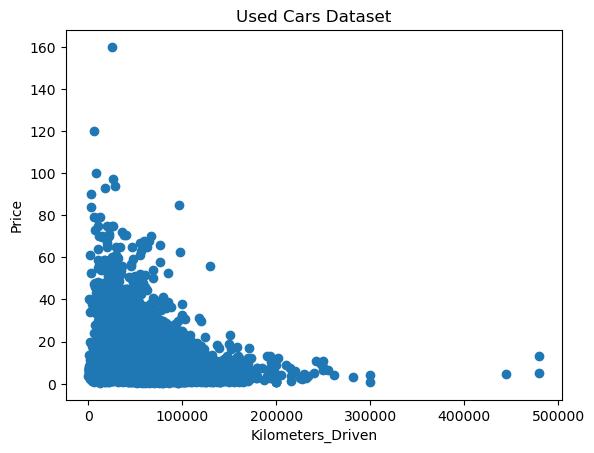

In [16]:
# 3. DATA VISUALIZATION
 
# --- Scatter plot: Price vs Kilometers Driven ---
fig, ax = plt.subplots()
ax.scatter(df['Kilometers_Driven'], df['Price'])
ax.set_title('Used Cars Dataset')
ax.set_xlabel('Kilometers_Driven')
ax.set_ylabel('Price')

Text(0, 0.5, 'Price')

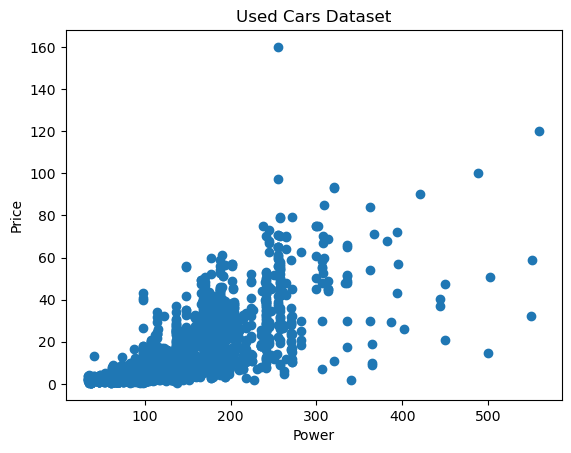

In [33]:
# --- Scatter plot: Price vs Power ---
fig, ax = plt.subplots()
ax.scatter(df['Power'], df['Price'])
ax.set_title('Used Cars Dataset')
ax.set_xlabel('Power')
ax.set_ylabel('Price')

Text(0, 0.5, 'Frequency')

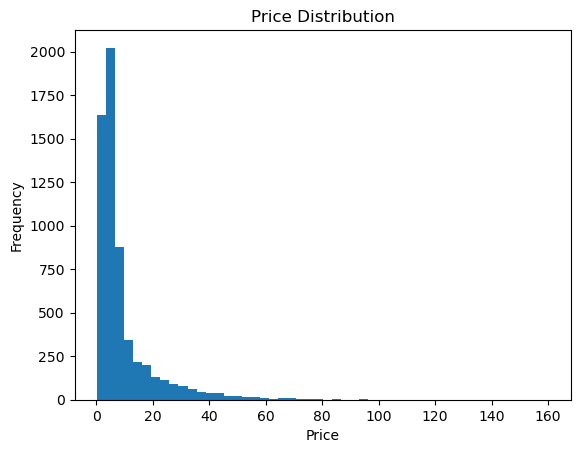

In [34]:
# --- Histogram: Price distribution ---
fig, ax = plt.subplots()
ax.hist(df['Price'], bins=50)
ax.set_title('Price Distribution')
ax.set_xlabel('Price')
ax.set_ylabel('Frequency')

Text(0, 0.5, 'Average Price')

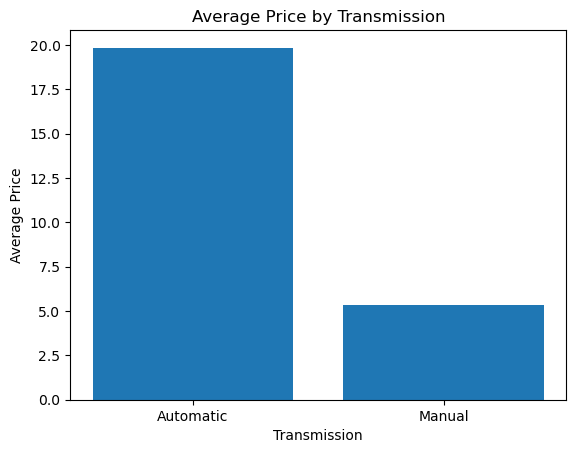

In [35]:
# --- Bar chart: average price by transmission ---
df_orig = pd.read_csv('data/used_cars_data.csv').dropna(subset=['Price'])
trans_mean = df_orig.groupby('Transmission')['Price'].mean()
fig, ax = plt.subplots()
ax.bar(trans_mean.index, trans_mean.values)
ax.set_title('Average Price by Transmission')
ax.set_xlabel('Transmission')
ax.set_ylabel('Average Price')

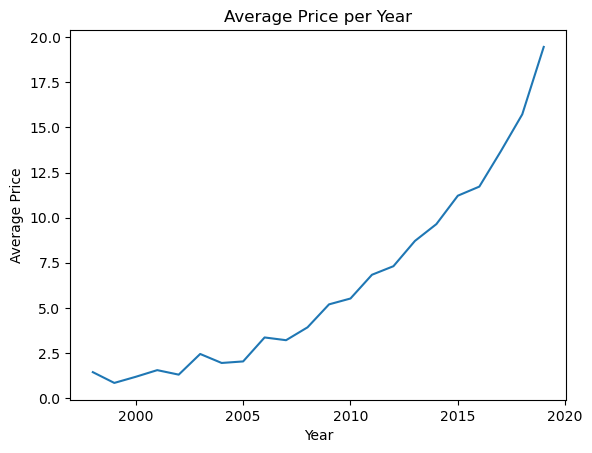

In [36]:
# --- Line chart: average price per year ---
year_mean = df.groupby('Year')['Price'].mean()
fig, ax = plt.subplots()
ax.plot(year_mean.index, year_mean.values)
ax.set_title('Average Price per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average Price')
 
plt.show()

In [21]:
# 4. PREPARE DATA FOR MODELING
# separate into X and y
# we use Year, Kilometers_Driven and Power as features (like the 3-variable example in class)
X = np.c_[df['Year'].values, df['Kilometers_Driven'].values, df['Power'].values]
y = np.c_[df['Price'].values]
 
print(X[0:3, :])
print(y[0:3])

[[2.010e+03 7.200e+04 5.816e+01]
 [2.015e+03 4.100e+04 1.262e+02]
 [2.011e+03 4.600e+04 8.870e+01]]
[[ 1.75]
 [12.5 ]
 [ 4.5 ]]


In [22]:
# normalize data: 1 subtract the mean; 2 divide the standard deviation
X_mean = np.mean(X, 0)
X_normalized = X - X_mean
X_std = np.std(X, 0)
X_normalized /= X_std

In [23]:
# add an additional column of 1 for X (bias term)
m = y.size
X_normalized = np.c_[np.ones(m), X_normalized]
 
print(X_mean)
print(X_std)
print(X_normalized[0:3, :])

[ 2013.35866312 57333.93930828   112.86445294]
[3.26995584e+00 3.49795276e+04 5.32650267e+01]
[[ 1.         -1.02712798  0.41927555 -1.02702385]
 [ 1.          0.50194466 -0.46695712  0.25036216]
 [ 1.         -0.72131345 -0.32401636 -0.45366452]]


In [24]:
# 5. LINEAR REGRESSION — FROM SCRATCH
# cost function
def computeCost(X, y, theta):
    m = y.size
    h = X_normalized.dot(theta)
    J = 1 / (2 * m) * np.sum((h - y) ** 2)
    return(J)
 
computeCost(X_normalized, y, [[0], [0], [0], [0]])

107.20750781509811

In [25]:
# gradient descent
def gradientDescent(X, y, theta, alpha=0.01, num_iters=50):
    m = y.size
    J_history = np.zeros(num_iters)
    for i in range(num_iters):
        h = X_normalized.dot(theta)
        theta[0] = theta[0] - (alpha / m) * np.sum(h - y)
        theta[1] = theta[1] - (alpha / m) * np.sum((h - y) * X[:, 1:2])
        theta[2] = theta[2] - (alpha / m) * np.sum((h - y) * X[:, 2:3])
        theta[3] = theta[3] - (alpha / m) * np.sum((h - y) * X[:, 3:4])
        J_history[i] = computeCost(X, y, theta)
    return(theta, J_history)

In [26]:
# run gradient descent with different learning rates
theta1, cost_J1 = gradientDescent(X_normalized, y, [[0], [0], [0], [0]], 0.1)
theta2, cost_J2 = gradientDescent(X_normalized, y, [[0], [0], [0], [0]], 0.03)
theta3, cost_J3 = gradientDescent(X_normalized, y, [[0], [0], [0], [0]], 0.01)

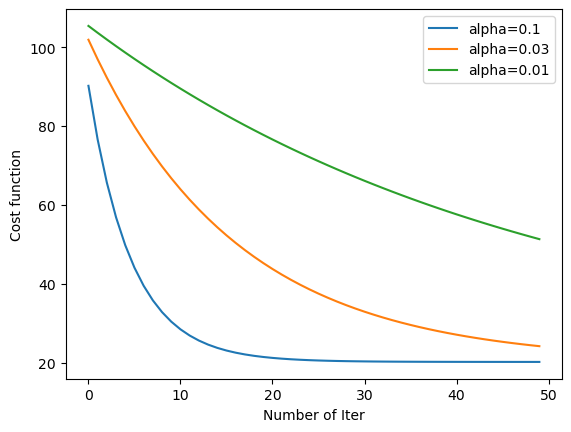

In [27]:
# plot
plt.plot(cost_J1, label='alpha=0.1')
plt.plot(cost_J2, label='alpha=0.03')
plt.plot(cost_J3, label='alpha=0.01')
plt.xlabel('Number of Iter')
plt.ylabel('Cost function')
plt.legend()
plt.show()

In [28]:
# make a prediction: Year=2015, Km=50000, Power=100 bhp
new_car = np.c_[2015, 50000, 100]
# normalize
new_car_normalized = (new_car - X_mean) / X_std
# predict
new_car_normalized = np.c_[1, new_car_normalized]
print(new_car_normalized.dot(theta1))

[[8.94293215]]


In [37]:
# 6. LINEAR REGRESSION — SCIKIT-LEARN 
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
# reload clean data for sklearn (use all features)
feature_cols = ['Year', 'Kilometers_Driven', 'Power']
X_sk = df[feature_cols].values
y_sk = df['Price'].values

In [39]:
# normalize
X_sk_mean = X_sk.mean(axis=0)
X_sk_std  = X_sk.std(axis=0)
X_sk_norm = (X_sk - X_sk_mean) / X_sk_std

In [40]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(X_sk_norm, y_sk, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4811, 3)
(1203, 3)
(4811,)
(1203,)


In [41]:
# fit the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [42]:
# print the coefficients
print(model.coef_)
print(model.intercept_)

[ 2.95180005 -0.64992063  8.66629576]
9.505621362175951


In [43]:
# evaluate
y_pred = model.predict(X_test)
print('MAE  :', mean_absolute_error(y_test, y_pred))
print('RMSE :', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R²   :', r2_score(y_test, y_pred))

MAE  : 3.9328381022551175
RMSE : 6.01430948338043
R²   : 0.6817727072162785


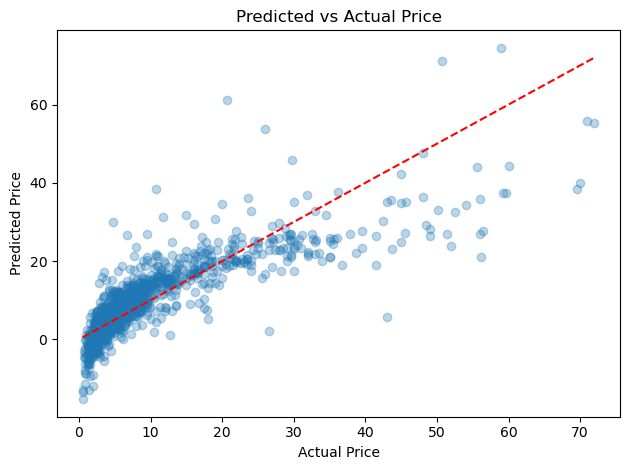

In [44]:
# plot predicted vs actual
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.3)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax.set_title('Predicted vs Actual Price')
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
plt.tight_layout()
plt.show()

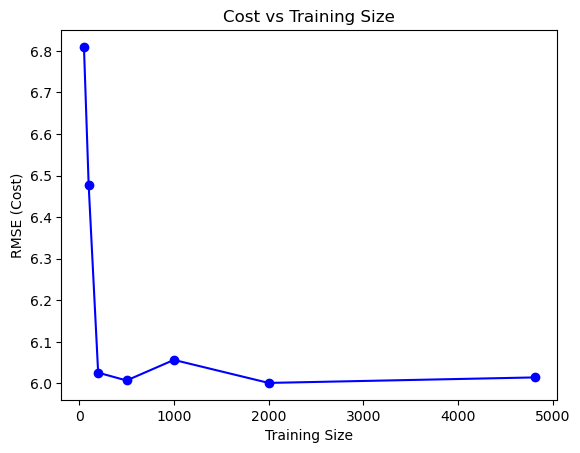

In [45]:
# cost (RMSE) vs training size
sizes = [50, 100, 200, 500, 1000, 2000, len(X_train)]
costs = []
for s in sizes:
    m = LinearRegression()
    m.fit(X_train[:s], y_train[:s])
    p = m.predict(X_test)
    costs.append(np.sqrt(mean_squared_error(y_test, p)))
 
plt.plot(sizes, costs, 'b-o')
plt.xlabel('Training Size')
plt.ylabel('RMSE (Cost)')
plt.title('Cost vs Training Size')
plt.show()

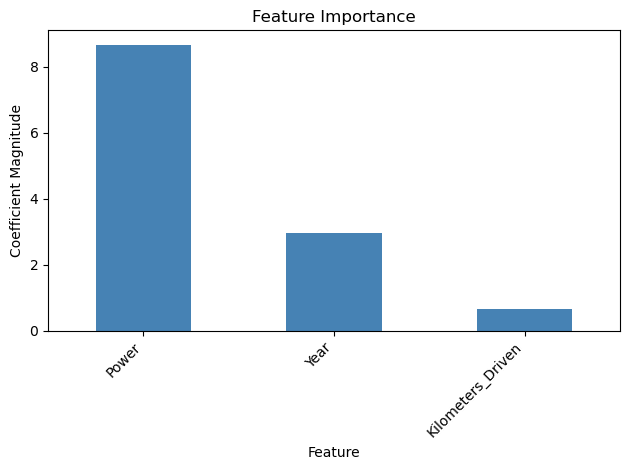

In [46]:
# feature importance (coefficients)
feature_names = ['Year', 'Kilometers_Driven', 'Power']
importance = pd.Series(model.coef_, index=feature_names)
importance.abs().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [48]:
# prediction function
def predict_price(year, kilometers, power):
    new_car = np.array([[year, kilometers, power]])
    new_car_norm = (new_car - X_sk_mean) / X_sk_std
    pred = model.predict(new_car_norm)
    print('=== Price Prediction ===')
    print(f'Estimated Price: {pred[0]:.2f} Lakhs')

In [49]:
predict_price(2015, 50000, 100)

=== Price Prediction ===
Estimated Price: 9.03 Lakhs
